In [1]:
import cfe

# cfe.logger.setLevel("INFO")
cfe.logger.setLevel("DEBUG")

# cfe.settings.backend = "python_function"
cfe.settings.backend = "conda"
# cfe.settings.backend = "cfe_docker"

cfe.settings.save_external_data = True # save external data
cfe.settings.save_h5ad = True # save external data

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

data

In [2]:
fadata = cfe.data.read_pancrease()

model_name = "cellrank_n_states_10"
fadata.load_trajectory_dict(model_name_list=[model_name])
fadata.model_name = model_name
fadata

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

infer trajectory

In [3]:
# n_states = 10

# parameters = {
#     "reprocess": False,
#     "wrapper_type": "lineage",  
#     # "kernel": "velocity", # may corrupt when compute_fate_probabilities
#     "fit_kwargs": {"n_states": n_states},
#     "initial_states": ["Ductal"],
#     "terminal_states": ["Alpha", "Beta", "Epsilon", "Delta"], 
#     # "predict_terminal_states_kwargs": {
#     #     "method": "stability",
#     # }
# }
# if parameters.get("kernel") == "velocity":
#     # try to use scvelo kernel
#     import scvelo as scv
#     scv.pp.filter_and_normalize(fadata, n_top_genes=2000)
#     scv.pp.moments(fadata, n_pcs=30, n_neighbors=30)

#     scv.tl.velocity(fadata, mode="dynamical")
#     scv.tl.velocity_graph(fadata)

#     scv.pl.velocity_embedding_stream(fadata, basis="umap")
#     parameters["reprocess"] = False

# method = cfe.method.FateMethod(method_name="cellrank")
# method.infer_trajectory(fadata, parameters=parameters, id=f"cellrank_n_states_{n_states}")
# fadata.write_trajectory_dict()

wrapper visualization

DEBUG    |- extract 'clusters' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:cellrank_n_states_10, basis:X_umap.                                                                                                       
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                               

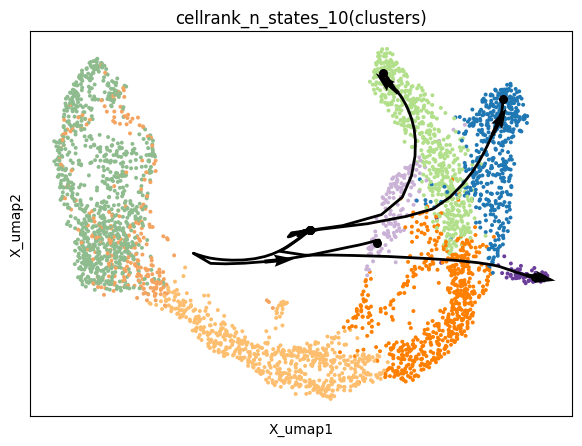

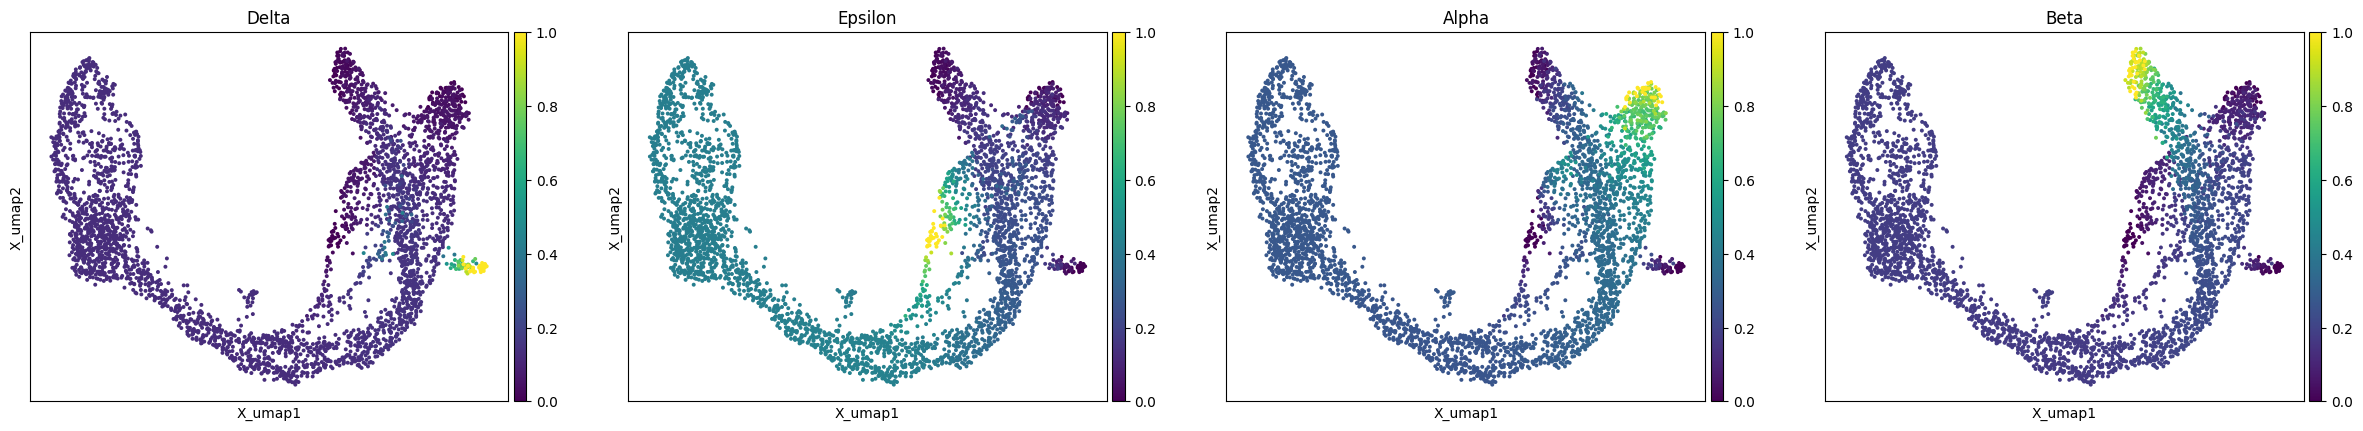

DEBUG    |- Dispatching to plotter 'probability' with mode 'star'.                                                                                                                                      


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index', 'term_states_fwd'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap', 'lineages_fwd', 'X_fate_simplex_fwd'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

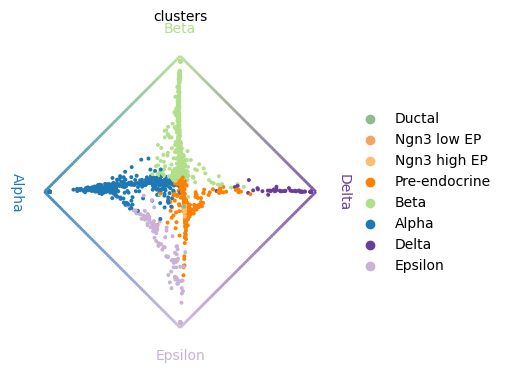

In [4]:
cfe.plot.plot_trajectory(fadata, save=True)
cfe.plot.plot_wrapper_new(fadata, wrapper_type="probability", mode="embedding")
cfe.plot.plot_wrapper_new(fadata, wrapper_type="probability", mode="star")
fadata

In [5]:
raw_wrapper_dict = fadata.get_trajectory_dict()["raw_wrapper_dict"]
probability = raw_wrapper_dict["probability"]
probability = probability.drop(columns=["cell_id"])
probability

,Delta,Epsilon,Alpha,Beta
cell_000,0.145926,0.258193,0.355043,0.240791
cell_001,0.127959,0.422233,0.271982,0.177473
cell_002,0.125897,0.235310,0.426387,0.212371
cell_003,0.128021,0.422077,0.272033,0.177506
cell_004,0.130625,0.417985,0.272840,0.178423
...,...,...,...,...
cell_3691,0.143330,0.295555,0.328814,0.232238
cell_3692,0.126686,0.437492,0.263595,0.172054
cell_3693,0.127979,0.422070,0.272067,0.177528
cell_3694,0.021653,0.059187,0.876244,0.042911


other lineage wrapper strategy

In [6]:
fadata.model_name = "base"
fadata.add_trajectory_lineage(
    probability=probability.copy(),
    cluster_key="clusters"
)
mw = fadata.get_milestone_wrapper()
mw.milestone_network

DEBUG    |- Adding lineage trajectory using 'base' strategy...                                                                                                                                          
DEBUG    |----- cluster_probability:                                                                                                                                                                    
                           Delta   Epsilon     Alpha      Beta                                                                                                                                          
         cluster                                                                                                                                                                                        
         Alpha          0.077995  0.168145  0.611727  0.142115                                                                                                                                      

,from,to,length,directed
0,milestone_begin,Delta,1,True
1,milestone_begin,Epsilon,1,True
2,milestone_begin,Alpha,1,True
3,milestone_begin,Beta,1,True


In [7]:
strategy = "graph_fusion"
fadata.model_name = strategy
fadata.add_trajectory_lineage(
    probability=probability.copy(),
    cluster_key="clusters",
    strategy=strategy
)
# cfe.plot.plot_trajectory(fadata)
# cfe.plot.plot_graph(fadata, color="clusters")
mw = fadata.get_milestone_wrapper()
mw.milestone_network

DEBUG    |- Adding lineage trajectory using 'graph_fusion' strategy...                                                                                                                                  
DEBUG    |----- Strategy 'graph_fusion': Identified root milestone: 'Ductal'                                                                                                                            
DEBUG    |- FateAnnData add_trajectory                                                                                                                                                                  
DEBUG    |- Successfully added lineage trajectory using 'graph_fusion' strategy.                                                                                                                        


,from,to,length,directed
0,Ductal,Pre-endocrine,1.0,True
1,Pre-endocrine,Delta,1.0,True
2,Pre-endocrine,Alpha,1.0,True
3,Pre-endocrine,Beta,1.0,True


In [8]:
strategy = "hierarchical_clustering"
fadata.model_name = strategy
fadata.add_trajectory_lineage(
    probability=probability.copy(),
    cluster_key="clusters",
    strategy=strategy,
    map_to_clusters=False, # 不使用名称映射
)
# cfe.plot.plot_trajectory(fadata)
# cfe.plot.plot_graph(fadata, color="clusters")
mw = fadata.get_milestone_wrapper()
mw.milestone_network

DEBUG    |- Adding lineage trajectory using 'hierarchical_clustering' strategy...                                                                                                                       
DEBUG    |----- Strategy 'hierarchical': Using abstract branch names.                                                                                                                                   
DEBUG    |- FateAnnData add_trajectory                                                                                                                                                                  
DEBUG    |- Successfully added lineage trajectory using 'hierarchical_clustering' strategy.                                                                                                             


,from,to,length,directed
0,Branch_1,Alpha,1.0,True
1,Branch_1,Beta,1.0,True
2,Branch_2,Epsilon,1.0,True
3,Branch_2,Branch_1,1.0,True
4,Branch_3,Delta,1.0,True
5,Branch_3,Branch_2,1.0,True
6,Root,Branch_3,1.0,True


DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:base, basis:X_umap.                                                                                                                       
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                                   
DEBUG    |- add waypoints shape is (204, 3696) for 'base', finished!                                                                                                                                

array([[<Axes: title={'center': 'base(clusters)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'graph_fusion(clusters)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'hierarchical_clustering(clusters)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

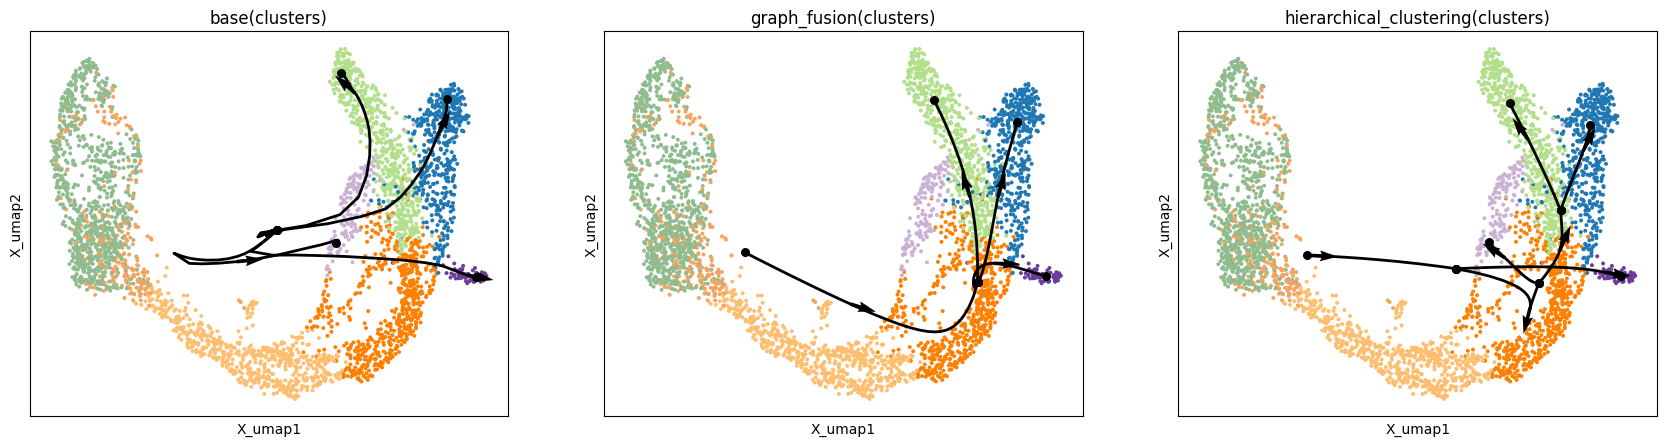

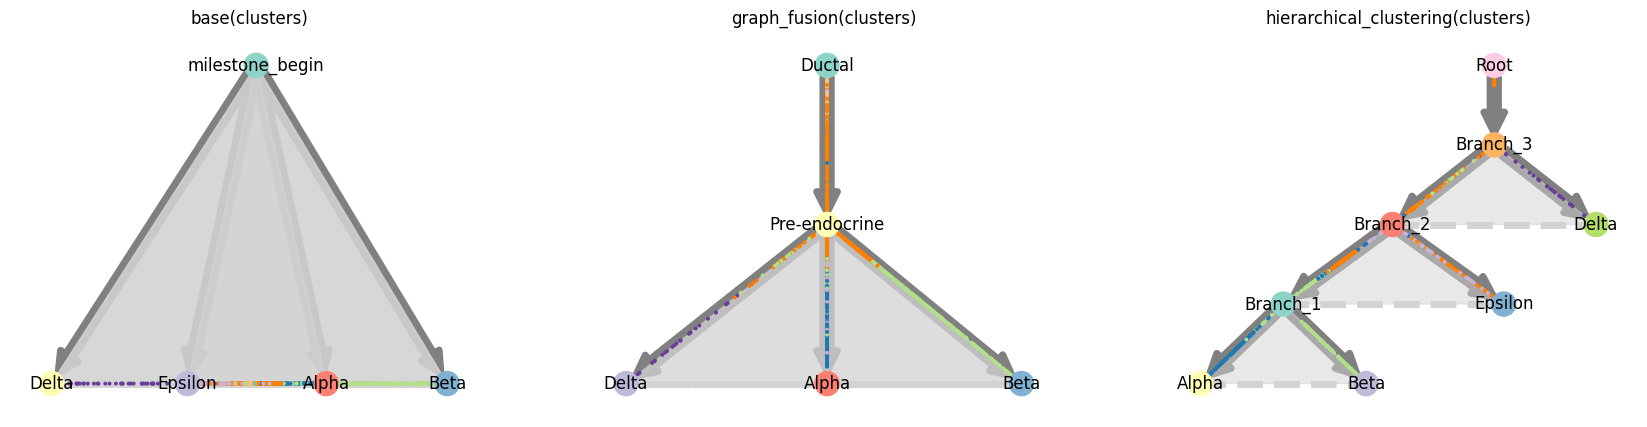

In [9]:
model_name_list = ["base", "graph_fusion", "hierarchical_clustering"]
cfe.plot.plot_trajectory(fadata, model_name= model_name_list, color="clusters")
cfe.plot.plot_graph(fadata, model_name= model_name_list, color="clusters")

TODO: visulization test case for paper